# Introdução
- Visto que o tratamento textual mais robusto não surgiu muito efeito, este estudo tem como objetivo escolher um número adequado para de features, ou melhor, o número adequado para o parâmetro "k_use": SelectKBest(chi2, k=k_use).
- O procedimento de escolha ficará automatizado nos estudos subsequentes.

# Imports e configs

In [1]:
import pandas as pd
from tqdm.auto import tqdm
import os
import re
import numpy as np
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, average_precision_score,
    balanced_accuracy_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns

tqdm.pandas()

# Configs
split_path = '../data/split'
seed = 2025

import warnings
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*", category=UserWarning)

# Recuperação dos datasets

In [2]:
df_train_val = pd.read_csv('../data/split/train_val_set.csv')
df_train_val['text'] = df_train_val['title'] + ' ' + df_train_val['summary']
df_test = pd.read_csv('../data/split/test_set.csv')
df_test['text'] = df_test['title'] + ' ' + df_test['summary']
df_train_val.head(2)

,id,title,author,publication_date,summary,label,fold,text
0,620,animal farm,george orwell,1945.0,old major the old boar on the manor farm calls...,0,fold_3,animal farm old major the old boar on the mano...
1,843,a clockwork orange,anthony burgess,1962.0,alex a teenager living in nearfuture england l...,0,fold_2,a clockwork orange alex a teenager living in n...


# Rotinas avaliação

In [3]:
# =========================
# CONFIG GLOBAL: CHI² FIXO
# =========================
CHI2_K_FIXED = 10_000  # sempre aplicado


# =========================
# HELPERS DE MÉTRICAS/FORMATAÇÃO
# =========================
def roc_auc_safe(y_true, proba, classes_in_proba):
    """AUC binário ou OVR weighted para multi, robusto ao índice da classe positiva."""
    if len(classes_in_proba) == 2:
        pos_label = classes_in_proba[-1]
        pos_idx = list(classes_in_proba).index(pos_label)
        return roc_auc_score(y_true, proba[:, pos_idx])
    return roc_auc_score(y_true, proba, multi_class="ovr", average="weighted")


def gmeans_safe(y_true, y_pred, labels_sorted):
    # binário por premissa; mantém fallback seguro
    uniq = np.unique(y_true)
    if len(uniq) == 2:
        pos_label = labels_sorted[-1]
        g_bin = geometric_mean_score(y_true, y_pred, average="binary", pos_label=pos_label)
    else:
        g_bin = np.nan
    g_micro = geometric_mean_score(y_true, y_pred, average="micro")
    return g_bin, g_micro


def format_summary(results_detailed):
    rows = []
    for entry in results_detailed:
        row = {"Modelo": entry["Modelo"]}
        for metric, values in entry.items():
            if metric == "Modelo":
                continue
            arr = np.array(values, dtype=float)
            row[metric] = f"{np.mean(arr):.2f} ({np.min(arr):.2f}-{np.max(arr):.2f}) ± {np.std(arr, ddof=1):.2f}"
        rows.append(row)
    return pd.DataFrame(rows)


# =========================
# GRID DE X PARA RUS (X = majority/minority após RUS)
# =========================
def rus_grid():
    # nova faixa (reversa): 1..10 + 15,20,25,30,35
    return list(reversed(list(range(1, 11)) + [15, 20, 25, 30, 35]))


# =========================
# CROSS-VALIDATION (Chi²=10k fixo + RUS opcional)
# =========================
def run_folds(model, model_name, df, labels_sorted, use_class_weight, log_each_fold,
              undersample_X=None, seed=2025, plot=False):

    fold_metrics, cms, cms_norm = [], [], []
    print(f"[{model_name}] Chi2_K={CHI2_K_FIXED} | RUS_X={undersample_X}")

    for fold in tqdm(sorted(df['fold'].unique()), desc=f"Folds {model_name}", leave=True):
        # split
        train_mask = df['fold'] != fold
        val_mask   = ~train_mask

        X_train_text = df.loc[train_mask, 'text'].astype(str).values
        X_val_text   = df.loc[val_mask, 'text'].astype(str).values
        y_train = df.loc[train_mask, 'label'].values
        y_val   = df.loc[val_mask, 'label'].values

        # TF-IDF
        vect = TfidfVectorizer()
        X_train_full = vect.fit_transform(X_train_text)
        X_val_full   = vect.transform(X_val_text)

        # Chi² fixo em 10k (antes do RUS)
        k_use = min(CHI2_K_FIXED, X_train_full.shape[1])
        selector = SelectKBest(chi2, k=k_use)
        X_train = selector.fit_transform(X_train_full, y_train)
        X_val   = selector.transform(X_val_full)

        # RUS (apenas no treino), se solicitado
        if undersample_X is not None:
            # PROBLEMA BINÁRIO: ratio = minority/majority = 1 / X
            # X = majority/minority desejado após RUS
            ratio = 1.0 / float(undersample_X)
            rus = RandomUnderSampler(sampling_strategy=ratio, random_state=seed)
            X_train, y_train = rus.fit_resample(X_train, y_train)

        # treino
        if use_class_weight and model_name == "NaiveBayes":
            sw = compute_sample_weight(class_weight='balanced', y=y_train)
            model.fit(X_train, y_train, sample_weight=sw)
        else:
            model.fit(X_train, y_train)

        # validação
        preds = model.predict(X_val)
        proba = model.predict_proba(X_val)

        g_bin, g_micro = gmeans_safe(y_val, preds, labels_sorted)
        metrics = {
            "Accuracy": accuracy_score(y_val, preds),
            "Precision": precision_score(y_val, preds, average="macro", zero_division=0),
            "Recall": recall_score(y_val, preds, average="macro", zero_division=0),
            "F1": f1_score(y_val, preds, average="macro", zero_division=0),
            "BalancedAccuracy": balanced_accuracy_score(y_val, preds),
            "GMean": g_bin,
            "GMeanMicro": g_micro,
            "AUPRC": average_precision_score(y_val, proba[:, 1])
        }
        fold_metrics.append(metrics)

        cm  = confusion_matrix(y_val, preds, labels=labels_sorted)
        cmn = confusion_matrix(y_val, preds, labels=labels_sorted, normalize="true")
        cms.append(cm); cms_norm.append(cmn)

        if log_each_fold:
            msg = " | ".join([f"{k}={v:.3f}" for k, v in metrics.items() if not np.isnan(v)])
            print(f"{model_name} | fold={fold} | {msg}")

    mean_cm = np.rint(np.mean(cms, axis=0)).astype(int)
    mean_cm_norm = np.mean(cms_norm, axis=0)

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        sns.heatmap(mean_cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[0])
        sns.heatmap(mean_cm_norm, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[1])
        plt.tight_layout()
        plt.show()

    return fold_metrics, mean_cm, mean_cm_norm


def evaluate_models(df, seed, use_class_weight=False, log_each_fold=False,
                    undersample_X=None, plot=False):
    """
    Executa CV para um valor específico de RUS (X = majority/minority), com Chi² fixo=10k.
    Retorna:
      - metrics_df: médias por modelo (uma linha por modelo)
      - metrics_summary: quadro "média (min-max) ± dp" por modelo
    """
    labels_sorted = np.array(sorted(df['label'].unique()))
    models = {
        "NaiveBayes": MultinomialNB(),
        "LogisticRegression": LogisticRegression(
            random_state=seed, **({"class_weight":"balanced"} if use_class_weight else {})
        ),
        "LightGBM": lgb.LGBMClassifier(
            random_state=seed, verbosity=-1, **({"class_weight":"balanced"} if use_class_weight else {})
        ),
    }

    rows_mean, results_detailed = [], []

    for model_name, model in models.items():
        start = time.perf_counter()
        fold_metrics, mean_cm, mean_cm_norm = run_folds(
            model, model_name, df, labels_sorted, use_class_weight, log_each_fold,
            undersample_X=undersample_X, seed=seed, plot=plot
        )
        elapsed = time.perf_counter() - start

        mean_vals = {k: np.nanmean([m[k] for m in fold_metrics]) for k in fold_metrics[0]}
        mean_vals.update({"Modelo": model_name, "Tempo_s": round(elapsed, 2), "Chi2_K": CHI2_K_FIXED})
        if undersample_X is not None:
            mean_vals.update({"X": undersample_X})
        rows_mean.append(mean_vals)

        detailed_vals = {"Modelo": model_name}
        for k in fold_metrics[0]:
            detailed_vals[k] = [m[k] for m in fold_metrics]
        results_detailed.append(detailed_vals)

    metrics_df = pd.DataFrame(rows_mean).round(3)
    metrics_summary = format_summary(results_detailed)
    return metrics_df, metrics_summary


# =========================
# TESTE HOLD-OUT (Chi²=10k fixo + RUS opcional)
# =========================
def evaluate_on_test(train_df, test_df, seed, use_class_weight=False, undersample_X=None, plot=False):
    labels_sorted = np.array(sorted(train_df['label'].unique()))

    models = {
        "NaiveBayes": MultinomialNB(),
        "LogisticRegression": LogisticRegression(
            random_state=seed, **({"class_weight": "balanced"} if use_class_weight else {})
        ),
        "LightGBM": lgb.LGBMClassifier(
            random_state=seed, verbosity=-1, **({"class_weight": "balanced"} if use_class_weight else {})
        ),
    }

    X_train_text = train_df['text'].astype(str).values
    y_train = train_df['label'].values
    X_test_text  = test_df['text'].astype(str).values
    y_test       = test_df['label'].values

    rows = []
    for model_name, model in models.items():
        # TF-IDF
        vect = TfidfVectorizer()
        X_train_full = vect.fit_transform(X_train_text)
        X_test_full  = vect.transform(X_test_text)

        # Chi² fixo em 10k
        k_use = min(CHI2_K_FIXED, X_train_full.shape[1])
        selector = SelectKBest(chi2, k=k_use)
        X_train_use = selector.fit_transform(X_train_full, y_train)
        X_test_use  = selector.transform(X_test_full)

        # RUS (apenas treino), se solicitado
        if undersample_X is not None:
            ratio = 1.0 / float(undersample_X)  # minority/majority desejado
            rus = RandomUnderSampler(sampling_strategy=ratio, random_state=seed)
            X_train_use, y_train_res = rus.fit_resample(X_train_use, y_train)
        else:
            y_train_res = y_train

        # treino
        if use_class_weight and model_name == "NaiveBayes":
            sw = compute_sample_weight(class_weight="balanced", y=y_train_res)
            model.fit(X_train_use, y_train_res, sample_weight=sw)
        else:
            model.fit(X_train_use, y_train_res)

        preds = model.predict(X_test_use)
        proba = model.predict_proba(X_test_use)

        g_bin, g_micro = gmeans_safe(y_test, preds, labels_sorted)
        metrics = {
            "Modelo": model_name,
            "X": undersample_X,
            "Chi2_K": CHI2_K_FIXED,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, average="macro", zero_division=0),
            "Recall": recall_score[y_test, preds] if False else recall_score(y_test, preds, average="macro", zero_division=0),
            "F1": f1_score(y_test, preds, average="macro", zero_division=0),
            "BalancedAccuracy": balanced_accuracy_score(y_test, preds),
            "GMean": g_bin,
            "GMeanMicro": g_micro,
            "AUPRC": average_precision_score(y_test, proba[:, 1])
        }
        rows.append(metrics)

        if plot:
            cm  = confusion_matrix(y_test, preds, labels=labels_sorted)
            cmn = confusion_matrix(y_test, preds, labels=labels_sorted, normalize="true")
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                        xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[0])
            sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues",
                        xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[1])
            plt.suptitle(f"{model_name} | X={undersample_X} | Chi2_K={CHI2_K_FIXED}")
            plt.tight_layout()
            plt.show()

    return pd.DataFrame(rows).round(3)


# =========================
# OUTROS AUXILIARES
# =========================
def get_train_test_by_total_with_folds(df_total):
    df = df_total.copy()
    df_test = df[df['fold'] == 'test'].copy().reset_index(drop=True)
    df_train_val = df[df['fold'] != 'test'].copy().reset_index(drop=True)
    return df_test, df_train_val


# =========================
# VISUALIZAÇÃO DE RESULTADOS (param_col configurável; ex.: "X")
# =========================
def _parse_metric_float(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, float, np.floating)): return float(x)
    m = re.search(r"[-+]?\d*\.\d+|[-+]?\d+", str(x))
    return float(m.group()) if m else np.nan

def plot_metrics_all_in_one_per_model(
    df_final,
    metrics=None,           # lista de métricas; None = detecta a partir do DF
    drop_baseline=False,    # compat
    out_dir=None,           # pasta para salvar PNGs; None = só mostrar
    dpi=120,
    ylim=(0, 1),            # limites do eixo y (None = auto)
    marker_cycle=("o","s","^","D","P","X","v",">","<"),
    linestyle_cycle=("-", "--", "-.", ":"),
    dup_jitter=0.08,        # deslocamento horizontal entre séries idênticas
    round_equal=6,          # casas decimais para decidir igualdade
    param_col="X"           # coluna do eixo x
):
    df = df_final.copy()

    if param_col not in df.columns:
        raise ValueError(f"df_cv_final precisa ter a coluna '{param_col}'.")
    if "Modelo" not in df.columns:
        raise ValueError("df_cv_final precisa ter a coluna 'Modelo'.")
    df = df[df[param_col]!='baseline']

    default_metrics = ["Accuracy","Precision","Recall","F1",
                       "BalancedAccuracy","GMean","GMeanMicro","AUPRC"]
    if metrics is None:
        metrics = [m for m in default_metrics if m in df.columns]
        if not metrics:
            raise ValueError("Nenhuma das métricas padrão foi encontrada no DataFrame.")
    else:
        missing = [m for m in metrics if m not in df.columns]
        if missing:
            raise ValueError(f"Métricas ausentes no DF: {missing}")

    # converter métricas em float
    for mcol in metrics:
        df[mcol] = pd.to_numeric(df[mcol].apply(_parse_metric_float), errors="coerce")

    # agrega por Modelo e param_col (média se houver várias linhas por valor)
    df_agg = df.groupby(["Modelo", param_col], as_index=False)[metrics].mean()

    # ordenar eixo x numericamente quando possível
    df_agg["_x_num"] = pd.to_numeric(df_agg[param_col], errors="coerce")
    order_x = df_agg.drop_duplicates(param_col).sort_values(["_x_num", param_col])[param_col].tolist()

    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    # uma figura por modelo
    for modelo, dmod in df_agg.groupby("Modelo"):
        dmod = dmod.copy()
        dmod["_x"] = pd.Categorical(dmod[param_col], categories=order_x, ordered=True)
        dmod = dmod.sort_values("_x")

        # posições numéricas + jitter
        x_labels = dmod["_x"].astype(str).tolist()
        x_pos = np.arange(len(x_labels))

        # detectar grupos de séries idênticas (após arredondar)
        series_map = {}
        for m in metrics:
            key = tuple(np.round(dmod[m].values.astype(float), round_equal))
            series_map.setdefault(key, []).append(m)

        # offsets por grupo de duplicatas
        offset_map = {}
        for key, mlist in series_map.items():
            g = len(mlist)
            if g == 1:
                offset_map[mlist[0]] = 0.0
            else:
                base = np.linspace(-(g-1)/2, (g-1)/2, g) * dup_jitter
                for met, off in zip(mlist, base):
                    offset_map[met] = off

        # plot
        plt.figure(figsize=(10, 5))
        for i, m in enumerate(metrics):
            off = offset_map.get(m, 0.0)
            ls  = linestyle_cycle[i % len(linestyle_cycle)]
            mk  = marker_cycle[i % len(marker_cycle)]
            plt.plot(x_pos + off, dmod[m].values, linestyle=ls, marker=mk, label=m)

        plt.xticks(x_pos, x_labels, rotation=45)
        plt.xlabel(param_col)
        plt.ylabel("valor")
        plt.title(f"Métricas por {param_col} — {modelo}")
        plt.grid(True, axis="y", linestyle="--", linewidth=0.6)
        if ylim is not None:
            plt.ylim(*ylim)
        plt.legend(title="Métrica", ncol=2)
        plt.tight_layout()

        if out_dir:
            fname = f"metrics_allinone_{str(modelo).replace(' ', '_')}_by_{param_col}.png"
            plt.savefig(os.path.join(out_dir, fname), dpi=dpi, bbox_inches="tight")
            print(f"[saved] {os.path.join(out_dir, fname)}")

        plt.show()

    return df_agg

### Validação cruzada

In [4]:
results_cv_all = []
for X in rus_grid():
    print(f"\n=== CV (Chi2->RUS) com RUS_X={X} ===")
    metrics_df, metrics_summary = evaluate_models(
        df_train_val,
        seed=2025,
        use_class_weight=True,
        log_each_fold=False,
        undersample_X=X,  
        plot=False
    )
    metrics_summary["RUS_X"] = X
    results_cv_all.append(metrics_summary)

df_cv_final = pd.concat(results_cv_all, ignore_index=True)
display(df_cv_final)



=== CV (Chi2->RUS) com RUS_X=35 ===
[NaiveBayes] Chi2_K=10000 | RUS_X=35


Folds NaiveBayes:   0%|          | 0/5 [00:00<?, ?it/s]

[LogisticRegression] Chi2_K=10000 | RUS_X=35


Folds LogisticRegression:   0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] Chi2_K=10000 | RUS_X=35


...

[LogisticRegression] Chi2_K=10000 | RUS_X=1


Folds LogisticRegression:   0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] Chi2_K=10000 | RUS_X=1


Folds LightGBM:   0%|          | 0/5 [00:00<?, ?it/s]

,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC,RUS_X
0,NaiveBayes,0.98 (0.98-0.99) ± 0.00,0.83 (0.81-0.85) ± 0.02,0.82 (0.79-0.84) ± 0.02,0.82 (0.80-0.84) ± 0.02,0.82 (0.79-0.84) ± 0.02,0.80 (0.76-0.83) ± 0.02,0.98 (0.98-0.99) ± 0.00,0.72 (0.66-0.80) ± 0.05,35
1,LogisticRegression,0.98 (0.98-0.99) ± 0.00,0.84 (0.82-0.87) ± 0.02,0.83 (0.79-0.86) ± 0.03,0.83 (0.81-0.86) ± 0.02,0.83 (0.79-0.86) ± 0.03,0.81 (0.77-0.85) ± 0.04,0.98 (0.98-0.99) ± 0.00,0.73 (0.67-0.78) ± 0.05,35
2,LightGBM,0.98 (0.98-0.98) ± 0.00,0.88 (0.85-0.89) ± 0.02,0.71 (0.67-0.73) ± 0.03,0.77 (0.74-0.79) ± 0.02,0.71 (0.67-0.73) ± 0.03,0.65 (0.59-0.69) ± 0.04,0.98 (0.98-0.98) ± 0.00,0.63 (0.59-0.67) ± 0.03,35
3,NaiveBayes,0.98 (0.98-0.99) ± 0.00,0.83 (0.81-0.85) ± 0.01,0.82 (0.81-0.84) ± 0.01,0.83 (0.81-0.84) ± 0.01,0.82 (0.81-0.84) ± 0.01,0.81 (0.80-0.83) ± 0.01,0.98 (0.98-0.99) ± 0.00,0.72 (0.66-0.80) ± 0.05,30
4,LogisticRegression,0.98 (0.98-0.99) ± 0.00,0.84 (0.81-0.87) ± 0.03,0.84 (0.80-0.86) ± 0.02,0.84 (0.82-0.86) ± 0.02,0.84 (0.80-0.86) ± 0.02,0.82 (0.78-0.85) ± 0.03,0.98 (0.98-0.99) ± 0.00,0.73 (0.67-0.78) ± 0.05,30
5,LightGBM,0.98 (0.98-0.98) ± 0.00,0.87 (0.84-0.89) ± 0.02,0.72 (0.69-0.76) ± 0.03,0.77 (0.75-0.81) ± 0.02,0.72 (0.69-0.76) ± 0.03,0.66 (0.61-0.72) ± 0.04,0.98 (0.98-0.98) ± 0.00,0.62 (0.60-0.66) ± 0.02,30
6,NaiveBayes,0.98 (0.98-0.99) ± 0.00,0.83 (0.80-0.85) ± 0.02,0.83 (0.82-0.86) ± 0.02,0.83 (0.81-0.85) ± 0.01,0.83 (0.82-0.86) ± 0.02,0.81 (0.80-0.85) ± 0.02,0.98 (0.98-0.99) ± 0.00,0.72 (0.66-0.80) ± 0.05,25
7,LogisticRegression,0.98 (0.98-0.99) ± 0.00,0.83 (0.81-0.84) ± 0.01,0.84 (0.82-0.86) ± 0.02,0.83 (0.82-0.85) ± 0.01,0.84 (0.82-0.86) ± 0.02,0.83 (0.80-0.85) ± 0.03,0.98 (0.98-0.99) ± 0.00,0.72 (0.67-0.78) ± 0.05,25
8,LightGBM,0.98 (0.98-0.99) ± 0.00,0.85 (0.78-0.89) ± 0.04,0.73 (0.69-0.76) ± 0.04,0.77 (0.72-0.81) ± 0.04,0.73 (0.69-0.76) ± 0.04,0.68 (0.61-0.73) ± 0.05,0.98 (0.98-0.99) ± 0.00,0.62 (0.59-0.64) ± 0.02,25
9,NaiveBayes,0.98 (0.98-0.99) ± 0.00,0.82 (0.79-0.84) ± 0.02,0.84 (0.82-0.87) ± 0.02,0.83 (0.81-0.85) ± 0.02,0.84 (0.82-0.87) ± 0.02,0.83 (0.80-0.86) ± 0.02,0.98 (0.98-0.99) ± 0.00,0.73 (0.66-0.81) ± 0.05,20


### Avaliação no conjunto de teste

In [5]:
hold_rows = []
for X in rus_grid():
    print(f"== Hold-out (Chi2->RUS) com X={X} ==")
    df_hold = evaluate_on_test(
        df_train_val, df_test,
        seed=2025,
        use_class_weight=True,
        undersample_X=X,   # RUS só no treino; teste fica puro
        plot=False
    )
    df_hold["RUS_X"] = X
    hold_rows.append(df_hold)

df_test_final = pd.concat(hold_rows, ignore_index=True)
display(df_test_final)


== Hold-out (Chi2->RUS) com X=35 ==
== Hold-out (Chi2->RUS) com X=30 ==
== Hold-out (Chi2->RUS) com X=25 ==
== Hold-out (Chi2->RUS) com X=20 ==
== Hold-out (Chi2->RUS) com X=15 ==
== Hold-out (Chi2->RUS) com X=10 ==
== Hold-out (Chi2->RUS) com X=9 ==
== Hold-out (Chi2->RUS) com X=8 ==
== Hold-out (Chi2->RUS) com X=7 ==
== Hold-out (Chi2->RUS) com X=6 ==
== Hold-out (Chi2->RUS) com X=5 ==
== Hold-out (Chi2->RUS) com X=4 ==
== Hold-out (Chi2->RUS) com X=3 ==
== Hold-out (Chi2->RUS) com X=2 ==
== Hold-out (Chi2->RUS) com X=1 ==


,Modelo,X,Chi2_K,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC,RUS_X
0,NaiveBayes,35,10000,0.984,0.857,0.781,0.814,0.781,0.751,0.984,0.633,35
1,LogisticRegression,35,10000,0.986,0.864,0.835,0.848,0.835,0.819,0.986,0.632,35
2,LightGBM,35,10000,0.981,0.861,0.687,0.745,0.687,0.614,0.981,0.588,35
3,NaiveBayes,30,10000,0.983,0.844,0.781,0.809,0.781,0.751,0.983,0.648,30
4,LogisticRegression,30,10000,0.986,0.864,0.835,0.848,0.835,0.819,0.986,0.636,30
5,LightGBM,30,10000,0.981,0.850,0.701,0.754,0.701,0.635,0.981,0.559,30
6,NaiveBayes,25,10000,0.981,0.813,0.780,0.795,0.780,0.750,0.981,0.653,25
7,LogisticRegression,25,10000,0.984,0.834,0.834,0.834,0.834,0.819,0.984,0.629,25
8,LightGBM,25,10000,0.979,0.797,0.726,0.756,0.726,0.675,0.979,0.590,25
9,NaiveBayes,20,10000,0.984,0.838,0.821,0.829,0.821,0.802,0.984,0.662,20


# Save Results

In [6]:
# Caminhos relativos baseline
cv_path   = "../results/baseline/cv_baseline.csv"
test_path = "../results/baseline/test_baseline.csv"

# Carregar
df_cv   = pd.read_csv(cv_path)
df_test = pd.read_csv(test_path)

df_cv_final = pd.concat([df_cv_final, df_cv], ignore_index=True).fillna('baseline')
df_test_final = pd.concat([df_test_final, df_test], ignore_index=True).fillna('baseline')

# Caminho da pasta de saída
out_dir = "../results/rus_after"
os.makedirs(out_dir, exist_ok=True)

# Salvar arquivos
df_cv_final.to_csv(os.path.join(out_dir, "cv_rus_after.csv"), index=False)
df_test_final.to_csv(os.path.join(out_dir, "test_rus_after.csv"), index=False)

print("Arquivos salvos em:", out_dir)

Arquivos salvos em: ../results/rus_after


# Vizualização dos resultados sobre validação cruzada
- De modo geral, observa-se o cenario em que métricas que acompanham o recall decrescem com o aumento do fator de undersampling (1/ratio), o que é esperado, pois aumenta-se a proporção da classe majoritária. Conforme aumenta-se a proporção da classe majoritária no treinamento, aumenta-se a precisão macro, F1 macro e também métricas governadas pela classe majoritária. 

# Obs: 
- Não encontrou-se ponto evidentemente melhor em desempenho do que aquele em que não se faz undersampling (k=10_000 do notebook 03), somente para casos em que se queira trocar recall/bal_acc por precision ou vice-versa (o que pode ser interessante dependendo do contexto).

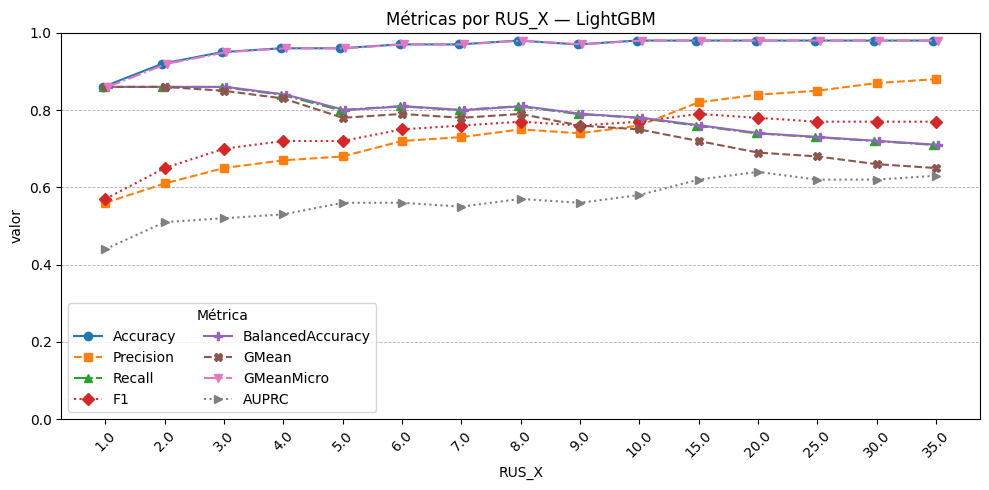

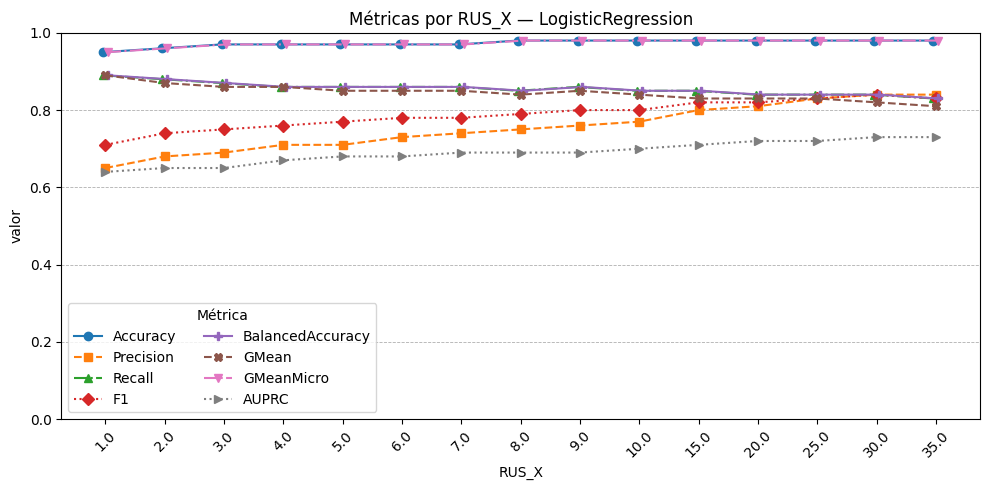

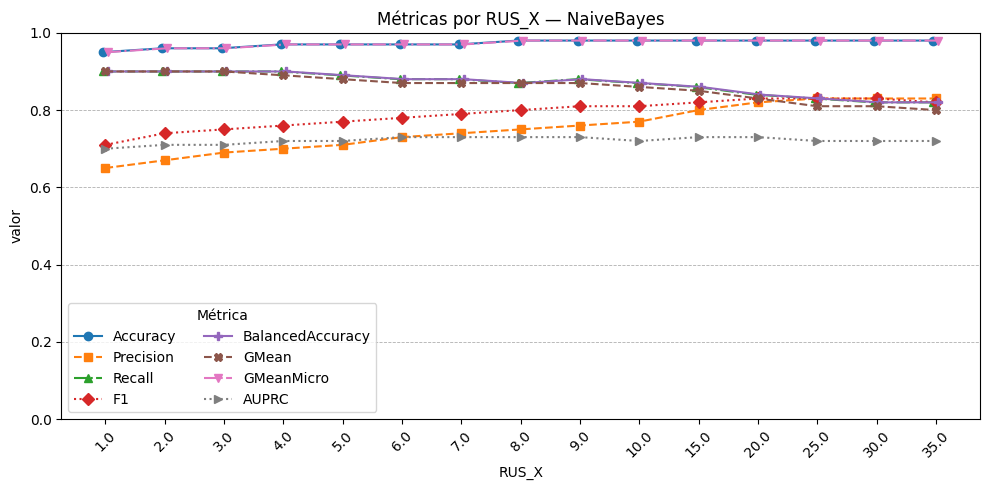

,Modelo,RUS_X,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC,_x_num
0,LightGBM,1.0,0.86,0.56,0.86,0.57,0.86,0.86,0.86,0.44,1.0
1,LightGBM,2.0,0.92,0.61,0.86,0.65,0.86,0.86,0.92,0.51,2.0
2,LightGBM,3.0,0.95,0.65,0.86,0.70,0.86,0.85,0.95,0.52,3.0
3,LightGBM,4.0,0.96,0.67,0.84,0.72,0.84,0.83,0.96,0.53,4.0
4,LightGBM,5.0,0.96,0.68,0.80,0.72,0.80,0.78,0.96,0.56,5.0
5,LightGBM,6.0,0.97,0.72,0.81,0.75,0.81,0.79,0.97,0.56,6.0
6,LightGBM,7.0,0.97,0.73,0.80,0.76,0.80,0.78,0.97,0.55,7.0
7,LightGBM,8.0,0.98,0.75,0.81,0.77,0.81,0.79,0.98,0.57,8.0
8,LightGBM,9.0,0.97,0.74,0.79,0.76,0.79,0.76,0.97,0.56,9.0
9,LightGBM,10.0,0.98,0.76,0.78,0.77,0.78,0.75,0.98,0.58,10.0


In [7]:
plot_metrics_all_in_one_per_model(df_cv_final, param_col='RUS_X')

# Comportamento no conjunto de teste
- Não é exatamente identico, porém apresenta uma evolução semelhante ao visto na cv

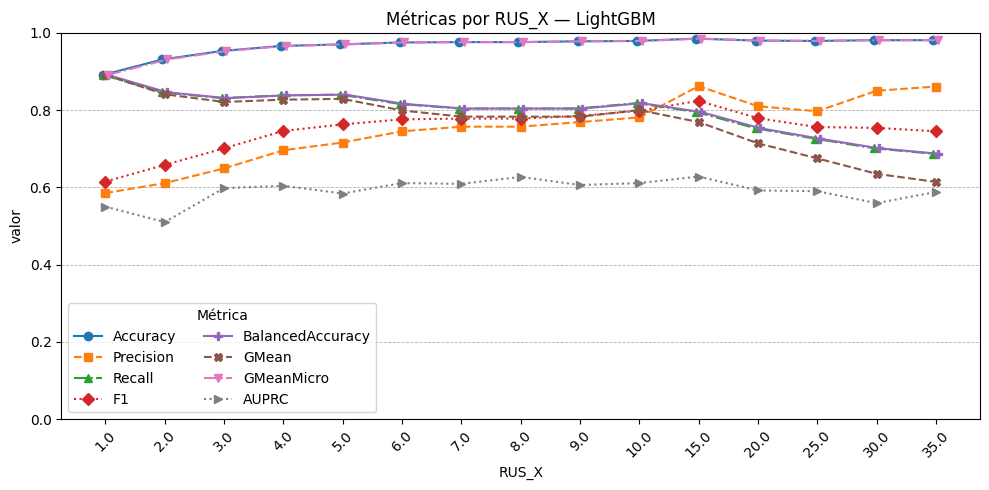

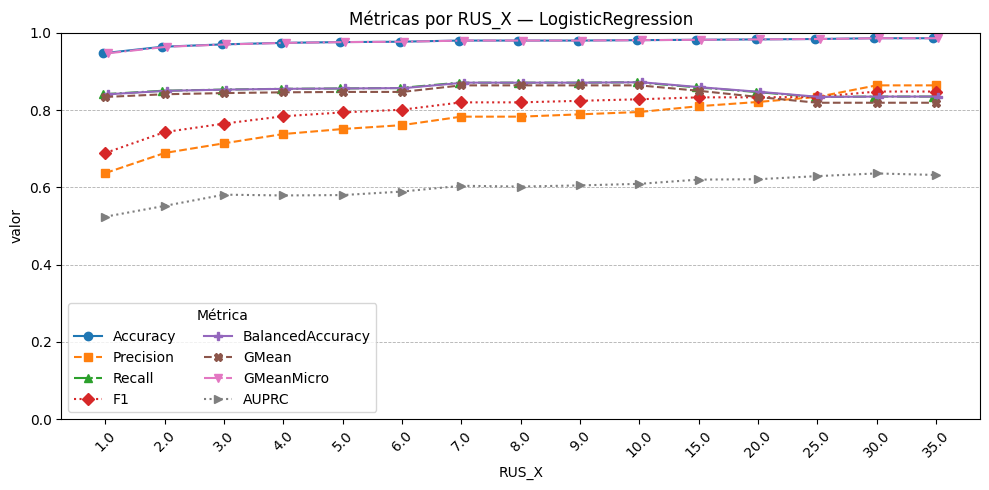

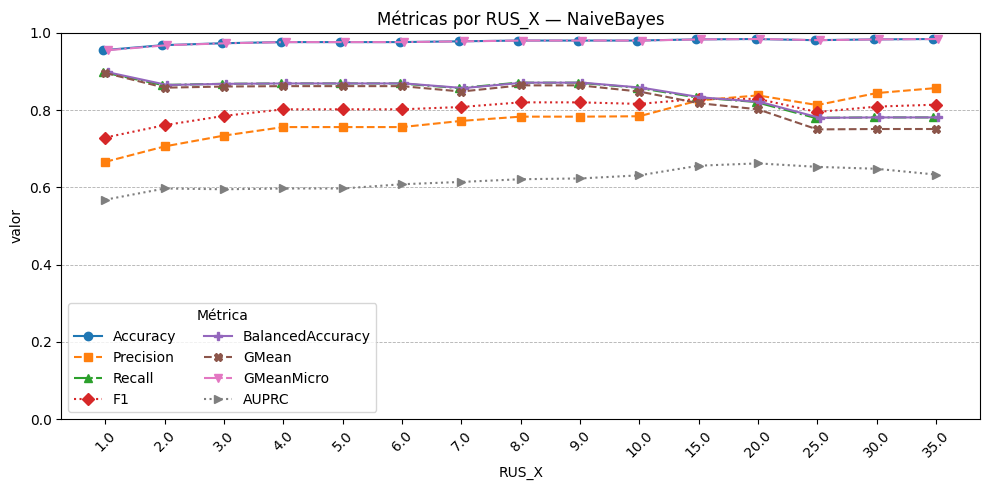

,Modelo,RUS_X,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC,_x_num
0,LightGBM,1.0,0.891,0.585,0.891,0.615,0.891,0.891,0.891,0.550,1.0
1,LightGBM,2.0,0.931,0.611,0.846,0.658,0.846,0.841,0.931,0.510,2.0
2,LightGBM,3.0,0.953,0.649,0.831,0.701,0.831,0.821,0.953,0.598,3.0
3,LightGBM,4.0,0.966,0.696,0.838,0.746,0.838,0.827,0.966,0.604,4.0
4,LightGBM,5.0,0.970,0.716,0.840,0.763,0.840,0.829,0.970,0.584,5.0
5,LightGBM,6.0,0.975,0.745,0.816,0.776,0.816,0.799,0.975,0.611,6.0
6,LightGBM,7.0,0.976,0.757,0.804,0.778,0.804,0.783,0.976,0.609,7.0
7,LightGBM,8.0,0.976,0.757,0.804,0.778,0.804,0.783,0.976,0.627,8.0
8,LightGBM,9.0,0.978,0.769,0.804,0.785,0.804,0.783,0.978,0.606,9.0
9,LightGBM,10.0,0.979,0.781,0.818,0.798,0.818,0.800,0.979,0.611,10.0


In [8]:
plot_metrics_all_in_one_per_model(df_test_final, param_col='RUS_X')

# Analises comparativas em se realizar os estudos utilizando RUS antes (notebook 6) ou depois (notebook 5) de feature selection
- Essa é uma análise posterior ao note 06
- Decisões tomadas em resultados CV: 
- Comportamentos muito semelhantes. 
    - Nota-se que os resultados obtidos quando se realiza o RUS antes da feature selection produziu, em geral, maiores flutuações na CV avaliação do LightGBM. 
- Nota-se algum descolamento maior do F1 e precision nos outros modelos, em favor da configurção de RUS após FS.
- Sem grande convicção, porém sem grande receio também, a opção de RUS após FS será preferida nos estudos subsequentes por se observar um comportamento um pouco mais "previsível", ou melhor, conter menos variação aleatória.

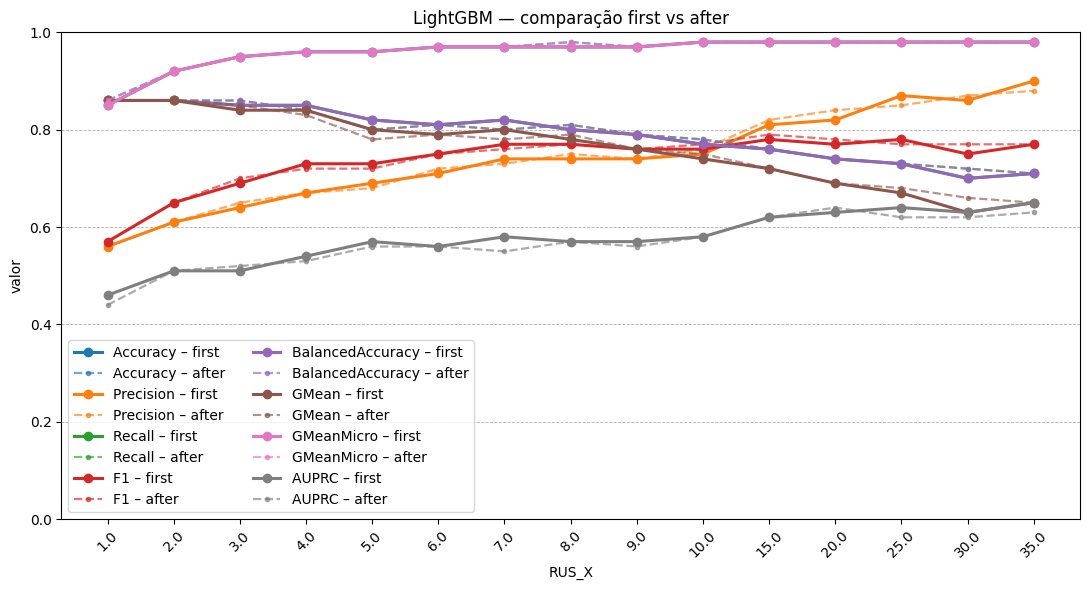

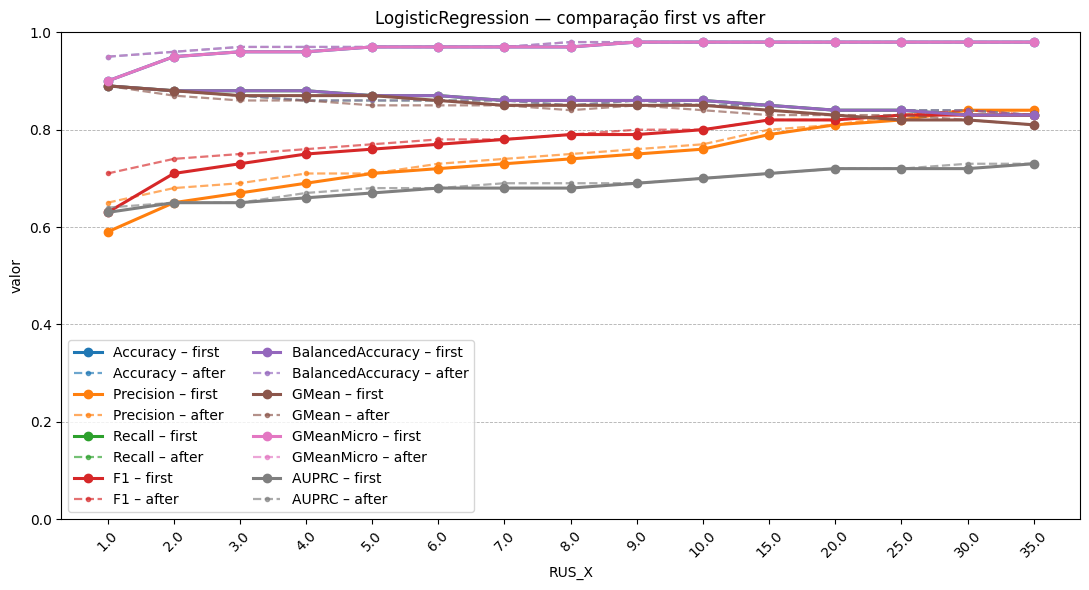

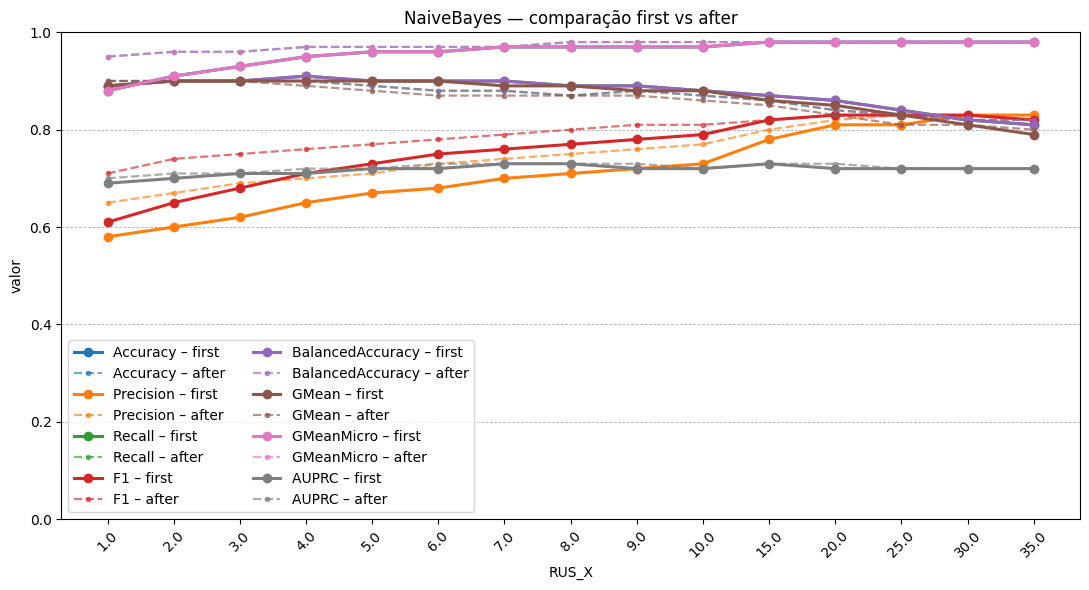

In [9]:
def _detect_param_col(df, prefer=("X","RUS_X","k")):
    for c in prefer:
        if c in df.columns:
            return c
    raise ValueError(f"Não achei coluna de parâmetro entre {prefer}.")

def _parse_metric_float(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, float, np.floating)): return float(x)
    import re
    m = re.search(r"[-+]?\d*\.\d+|[-+]?\d+", str(x))
    return float(m.group()) if m else np.nan

def _prepare_agg(df, metrics, param_col):
    df = df.copy()
    # remove "baseline" se existir
    if param_col in df.columns and df[param_col].dtype == object:
        df = df[df[param_col].astype(str) != "baseline"].copy()
    # métricas -> float
    for m in metrics:
        if m not in df.columns:
            raise ValueError(f"Métrica ausente: {m}")
        df[m] = pd.to_numeric(df[m].apply(_parse_metric_float), errors="coerce")
    # agrega por Modelo + parâmetro
    agg = df.groupby(["Modelo", param_col], as_index=False)[metrics].mean()
    return agg

def plot_compare_one_fig_per_model(
    df_first, df_after,
    metrics=None,
    param_col=None,
    label_first="first",
    label_after="after",
    subtle_run="after",           # visual mais discreto (linha tracejada) para "after" ou "first"
    ylim=(0,1),
    # salvar desativado por padrão:
    save=False, save_dir=None, save_format="png", save_dpi=120, verbose=False
):
    """
    Uma FIGURA por modelo, várias métricas. Para cada métrica: 2 curvas (first vs after).
    NADA é salvo a menos que save=True E save_dir seja fornecido.
    """
    default_metrics = ["Accuracy","Precision","Recall","F1",
                       "BalancedAccuracy","GMean","GMeanMicro","AUPRC"]
    metrics = metrics or [m for m in default_metrics if m in df_first.columns or m in df_after.columns]
    if not metrics:
        raise ValueError("Nenhuma métrica encontrada nos dataframes.")

    # detectar/alinhar coluna do eixo-x
    if param_col is None:
        param_first = _detect_param_col(df_first)
        param_col = param_first
        if param_col not in df_after.columns:
            param_after = _detect_param_col(df_after)
            if param_after != param_col:
                df_after = df_after.rename(columns={param_after: param_col})
    else:
        if param_col not in df_after.columns:
            alt = _detect_param_col(df_after)
            df_after = df_after.rename(columns={alt: param_col})

    # agrega
    agg_first = _prepare_agg(df_first, metrics, param_col)
    agg_after = _prepare_agg(df_after, metrics, param_col)

    # ordem unificada do eixo-x
    all_params = pd.concat([agg_first[[param_col]], agg_after[[param_col]]], ignore_index=True).drop_duplicates()
    all_params["_x_num"] = pd.to_numeric(all_params[param_col], errors="coerce")
    order_x = all_params.sort_values(["_x_num", param_col])[param_col].tolist()

    # paleta
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    if not color_cycle:
        color_cycle = ["C0","C1","C2","C3","C4","C5","C6","C7","C8","C9"]

    # modelos presentes em qualquer um dos DFs
    modelos = sorted(set(agg_first["Modelo"]).union(set(agg_after["Modelo"])))
    for modelo in modelos:
        d1 = agg_first[agg_first["Modelo"]==modelo].set_index(param_col)
        d2 = agg_after[agg_after["Modelo"]==modelo].set_index(param_col)

        x_pos = np.arange(len(order_x))

        plt.figure(figsize=(11,6))
        for i, met in enumerate(metrics):
            col = color_cycle[i % len(color_cycle)]

            y1 = [float(d1.loc[x, met]) if (x in d1.index and pd.notna(d1.loc[x, met])) else np.nan for x in order_x]
            y2 = [float(d2.loc[x, met]) if (x in d2.index and pd.notna(d2.loc[x, met])) else np.nan for x in order_x]

            strong = dict(linewidth=2.2, marker="o")
            subtle = dict(linewidth=1.6, linestyle="--", marker=".", alpha=0.65)

            if subtle_run.lower() == "after":
                plt.plot(x_pos, y1, label=f"{met} – {label_first}", color=col, **strong)
                plt.plot(x_pos, y2, label=f"{met} – {label_after}", color=col, **subtle)
            else:
                plt.plot(x_pos, y1, label=f"{met} – {label_first}", color=col, **subtle)
                plt.plot(x_pos, y2, label=f"{met} – {label_after}", color=col, **strong)

        plt.xticks(x_pos, [str(x) for x in order_x], rotation=45)
        plt.xlabel(param_col)
        plt.ylabel("valor")
        plt.title(f"{modelo} — comparação {label_first} vs {label_after}")
        plt.grid(True, axis="y", linestyle="--", linewidth=0.6)
        if ylim is not None:
            plt.ylim(*ylim)
        plt.legend(ncol=2)
        plt.tight_layout()

        # salvar somente se solicitado explicitamente
        if save:
            if not save_dir:
                raise ValueError("save=True, mas save_dir não foi informado.")
            os.makedirs(save_dir, exist_ok=True)
            fname = f"compare_onefig_{modelo}_by_{param_col}.{save_format}".replace(" ","_")
            path = os.path.join(save_dir, fname)
            plt.savefig(path, dpi=save_dpi, bbox_inches="tight")
            if verbose:
                print(f"saved: {path}")

        plt.show()


# caminhos (ajuste conforme seus saves)
cv_first_path  = "../results/rus_first/cv_rus_first.csv"
cv_after_path  = "../results/rus_after/cv_rus_after.csv"
test_first_path = "../results/rus_first/test_rus_first.csv"
test_after_path = "../results/rus_after/test_rus_after.csv"

df_cv_first  = pd.read_csv(cv_first_path)
df_cv_after  = pd.read_csv(cv_after_path)
df_test_first = pd.read_csv(test_first_path)
df_test_after = pd.read_csv(test_after_path)


plot_compare_one_fig_per_model(
    df_cv_first, df_cv_after,
    metrics=["Accuracy","Precision","Recall","F1",
                       "BalancedAccuracy","GMean","GMeanMicro","AUPRC"],
    param_col=None,            # autodetecta X/RUS_X/k
    label_first="first",
    label_after="after",
    subtle_run="after",        # visual discreto para "after"; legenda não fala “sutil/forte”
    ylim=(0,1),
    save=False                 # <- não salva
)


# Verificação no conjunto de Teste

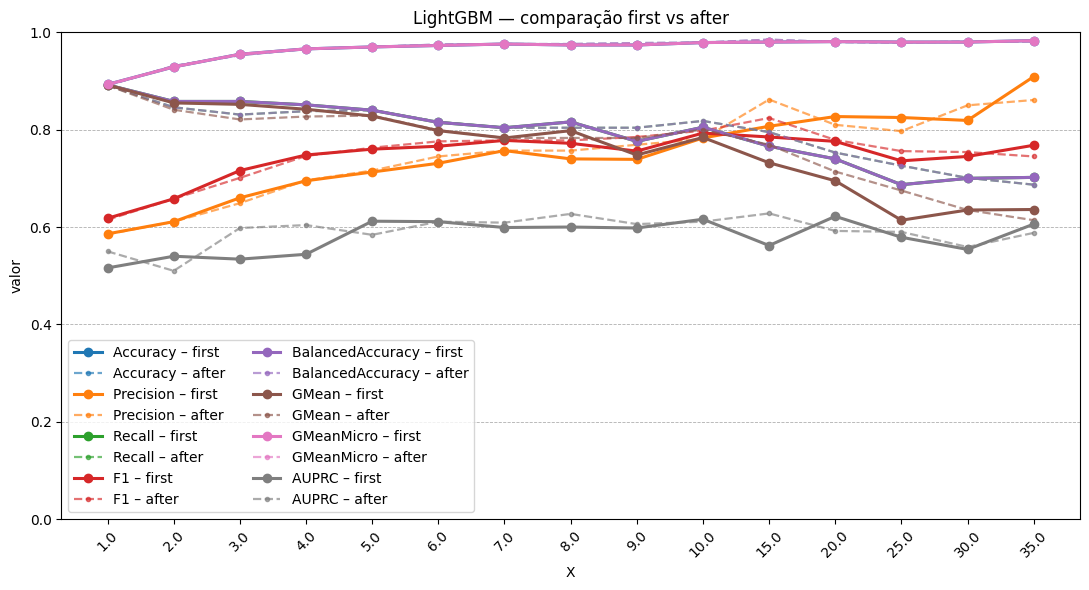

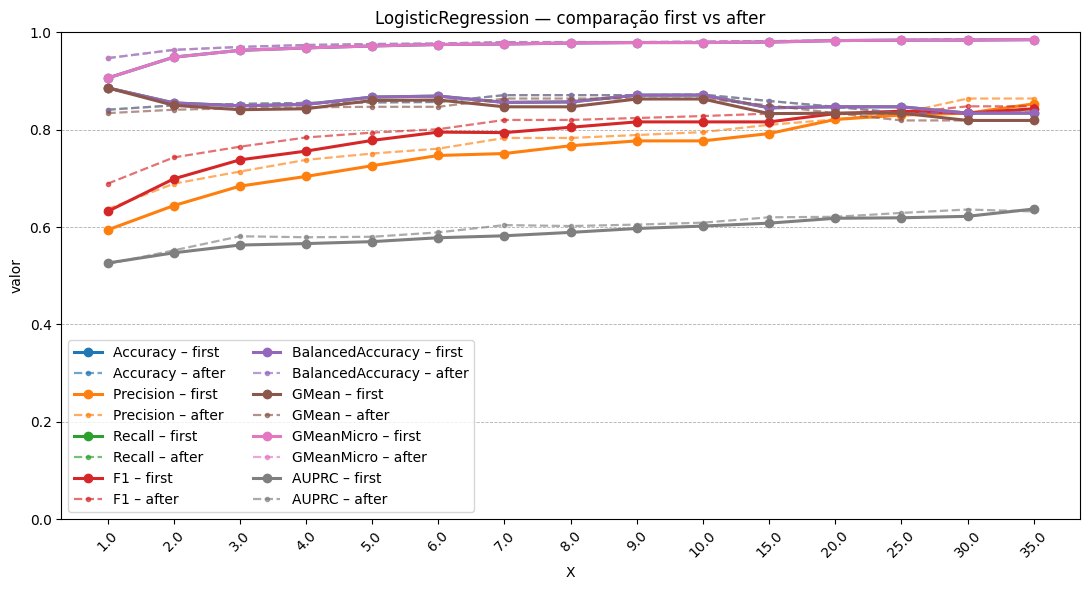

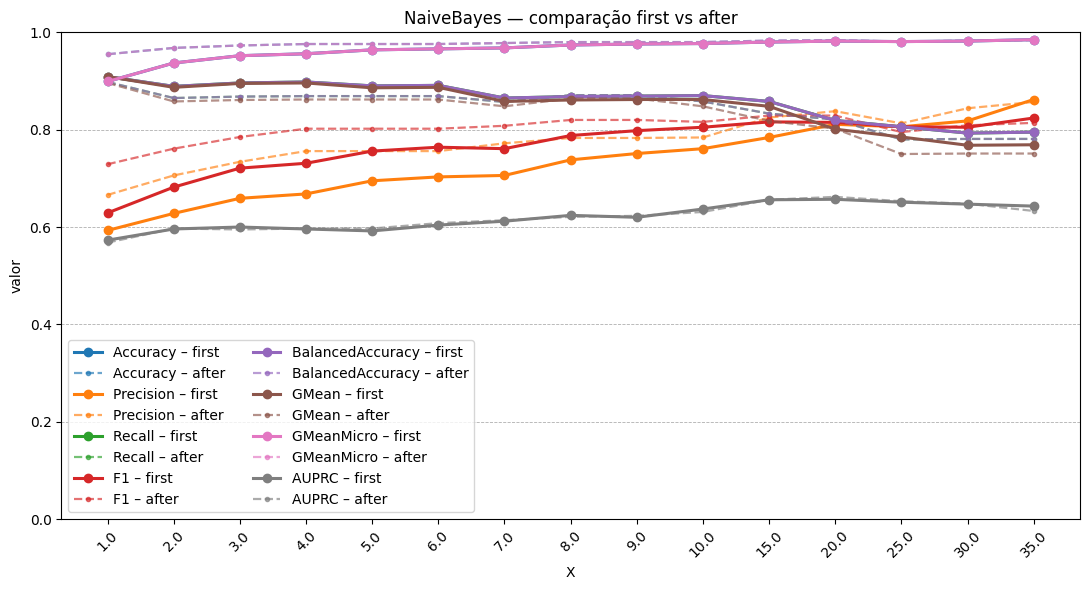

In [10]:
plot_compare_one_fig_per_model(
    df_test_first, df_test_after,
    metrics=["Accuracy","Precision","Recall","F1",
                       "BalancedAccuracy","GMean","GMeanMicro","AUPRC"],
    param_col=None,           
    label_first="first",
    label_after="after",
    subtle_run="after",
    ylim=(0,1),
    save=False 
)